# Accurate ArUco Marker Pose Estimation

**Goal:** use a calibrated camera to estimate the 3D position and orientation of an ArUco marker.

This notebook is designed for students who have just completed **Part A — Camera Calibration with ROS 2**.

By the end of this notebook, you should understand:

1. What an ArUco marker is.
2. Why ArUco markers are useful in robotics.
3. How camera calibration improves pose estimation.
4. How to detect an ArUco marker in an image.
5. How to estimate the marker pose using a calibrated camera.
6. How to visualize the estimated 3D coordinate frame on top of the image.

---

## What you need

You need:

- Python
- OpenCV with the `aruco` module
- NumPy
- Matplotlib
- PyYAML
- A calibrated camera YAML file from Part A
- A printed ArUco marker

In Part A, your calibration file was saved as something like:

```text
~/camera_calib_ws/calibration/laptop_camera.yaml
```

You will use that file in this notebook.


# 1. Background: What is an ArUco marker?

An **ArUco marker** is a square black-and-white fiducial marker.

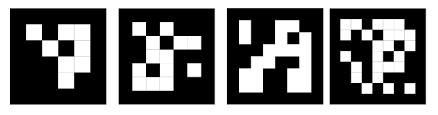

A fiducial marker is an artificial visual marker that is designed to be easy for a computer vision algorithm to detect.

You can think of it as a visual QR-code-like landmark for robots.

An ArUco marker has:

- a black square border,
- an inner binary pattern,
- a unique marker ID,
- four detectable corners.

The four corners are very important because they allow the computer to estimate the marker's 3D pose.

---

## Why are ArUco markers useful?

ArUco markers are useful because they turn a difficult perception problem into a simpler geometric problem.

Instead of asking:

> "Can the robot understand everything in the image?"

we ask:

> "Can the robot find this square marker and its four corners?"

This is much easier.

ArUco markers are commonly used for:

- robot localization,
- object tracking,
- camera pose estimation,
- augmented reality,
- calibration target detection,
- debugging spatial perception algorithms.

---

## What is pose estimation?

The **pose** of an object means:

```text
position + orientation
```

For an ArUco marker, pose estimation answers:

```text
Where is the marker relative to the camera?
How is the marker rotated relative to the camera?
```

In OpenCV, pose is represented by two vectors:

| Vector | Meaning |
|---|---|
| `rvec` | rotation vector |
| `tvec` | translation vector |

The translation vector `tvec` is especially intuitive:

```text
tvec = [x, y, z]
```

where:

- `x` is left/right position,
- `y` is up/down position,
- `z` is forward distance from camera.

The unit of `tvec` depends on the marker size unit you provide.

If marker size is in meters, `tvec` is also in meters.


# 2. Why camera calibration matters

A camera image is a 2D projection of the 3D world.

To estimate a marker pose, the computer needs to know the camera model.

The camera model includes:

- focal length,
- optical center,
- lens distortion.

These were estimated during camera calibration.

Without calibration, OpenCV does not know the real camera geometry. Pose estimation may still run, but the estimated distance and orientation can be wrong or unstable.

With calibration, the four detected marker corners can be interpreted geometrically.

In this notebook, we will use:

```text
2D marker corners in image + 3D marker corner coordinates + camera calibration = marker pose
```

This is a classic computer vision problem called **Perspective-n-Point**, or **PnP**.


# 3. Install Python dependencies

If you are running this notebook in the same environment as ROS 2, you may already have most packages installed.

Run the following cell if needed.

> Note: `opencv-contrib-python` is needed because the ArUco module is part of OpenCV's contributed modules in many Python installations.


In [ ]:
# Run this only if the imports in the next cell fail.
# In a normal ROS/pixi environment, your instructor may have already installed these.

# %pip install opencv-contrib-python numpy matplotlib pyyaml

# 4. Import libraries

In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

if not hasattr(cv2, "aruco"):
    raise ImportError(
        "cv2.aruco was not found. Install opencv-contrib-python or use a ROS/OpenCV build with ArUco support."
    )

print("ArUco module is available.")

# 5. Helper functions

These helper functions make the later cells easier to read.

They do four things:

1. Load a ROS camera calibration YAML file.
2. Generate and save an ArUco marker.
3. Detect ArUco markers in an image.
4. Estimate and draw the 3D pose axes.


In [ ]:
def load_ros_camera_calibration(yaml_path):
    """
    Load camera calibration from a ROS-style camera YAML file.

    Expected fields:
    - camera_matrix.data
    - distortion_coefficients.data
    """
    yaml_path = Path(yaml_path).expanduser()

    if not yaml_path.exists():
        raise FileNotFoundError(f"Calibration file not found: {yaml_path}")

    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    camera_matrix = np.array(data["camera_matrix"]["data"], dtype=np.float64).reshape(3, 3)
    dist_coeffs = np.array(data["distortion_coefficients"]["data"], dtype=np.float64).reshape(-1, 1)

    image_width = data.get("image_width", None)
    image_height = data.get("image_height", None)

    return camera_matrix, dist_coeffs, image_width, image_height


def show_image_bgr(image_bgr, title="Image", figsize=(8, 6)):
    """Display an OpenCV BGR image in a Jupyter notebook."""
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def get_aruco_dictionary(dictionary_name="DICT_6X6_250"):
    """Return an OpenCV ArUco dictionary object."""
    dictionary_id = getattr(cv2.aruco, dictionary_name)
    return cv2.aruco.getPredefinedDictionary(dictionary_id)


def create_aruco_detector(aruco_dict):
    """
    Create an ArUco detector in a way that works with modern OpenCV versions.

    OpenCV >= 4.7 uses cv2.aruco.ArucoDetector.
    Some older versions use cv2.aruco.detectMarkers directly.
    """
    parameters = cv2.aruco.DetectorParameters()

    if hasattr(cv2.aruco, "ArucoDetector"):
        detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
        return detector

    return None


def detect_aruco_markers(image_bgr, aruco_dict, detector=None):
    """Detect ArUco markers and return corners, ids, and rejected candidates."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    if detector is not None:
        corners, ids, rejected = detector.detectMarkers(gray)
    else:
        parameters = cv2.aruco.DetectorParameters_create()
        corners, ids, rejected = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=parameters)

    return corners, ids, rejected


def generate_marker(marker_id=23, marker_size_pixels=800, dictionary_name="DICT_6X6_250", output_path="aruco_marker_23.png"):
    """
    Generate an ArUco marker image and save it as a PNG file.

    Print this marker and measure the physical side length after printing.
    """
    aruco_dict = get_aruco_dictionary(dictionary_name)

    if hasattr(cv2.aruco, "generateImageMarker"):
        marker_img = cv2.aruco.generateImageMarker(aruco_dict, marker_id, marker_size_pixels)
    else:
        marker_img = np.zeros((marker_size_pixels, marker_size_pixels), dtype=np.uint8)
        cv2.aruco.drawMarker(aruco_dict, marker_id, marker_size_pixels, marker_img, 1)

    cv2.imwrite(str(output_path), marker_img)
    return marker_img


def marker_object_points(marker_length_m):
    """
    Define the 3D coordinates of the four marker corners.

    The marker coordinate frame is placed at the marker center.

    Corner order follows OpenCV ArUco convention:
    top-left, top-right, bottom-right, bottom-left in the marker image.
    """
    L = marker_length_m

    obj_points = np.array([
        [-L / 2.0,  L / 2.0, 0.0],
        [ L / 2.0,  L / 2.0, 0.0],
        [ L / 2.0, -L / 2.0, 0.0],
        [-L / 2.0, -L / 2.0, 0.0],
    ], dtype=np.float32)

    return obj_points


def estimate_pose_for_markers(corners, marker_length_m, camera_matrix, dist_coeffs):
    """
    Estimate pose for each detected marker using solvePnP.

    Returns a list of dictionaries.
    """
    obj_points = marker_object_points(marker_length_m)
    poses = []

    for marker_corners in corners:
        image_points = marker_corners.reshape(4, 2).astype(np.float32)

        success, rvec, tvec = cv2.solvePnP(
            obj_points,
            image_points,
            camera_matrix,
            dist_coeffs,
            flags=cv2.SOLVEPNP_IPPE_SQUARE
        )

        poses.append({
            "success": success,
            "rvec": rvec,
            "tvec": tvec
        })

    return poses


def draw_detections_and_axes(image_bgr, corners, ids, poses, camera_matrix, dist_coeffs, axis_length_m):
    """Draw detected marker boundaries and 3D coordinate axes."""
    output = image_bgr.copy()

    if ids is not None and len(ids) > 0:
        cv2.aruco.drawDetectedMarkers(output, corners, ids)

        for pose in poses:
            if pose["success"]:
                cv2.drawFrameAxes(
                    output,
                    camera_matrix,
                    dist_coeffs,
                    pose["rvec"],
                    pose["tvec"],
                    axis_length_m,
                    3
                )

    return output


def print_pose_summary(ids, poses):
    """Print marker pose in an easy-to-read format."""
    if ids is None or len(ids) == 0:
        print("No markers detected.")
        return

    for marker_id, pose in zip(ids.flatten(), poses):
        if not pose["success"]:
            print(f"Marker {marker_id}: pose estimation failed.")
            continue

        tvec = pose["tvec"].flatten()
        distance = np.linalg.norm(tvec)

        print(f"Marker ID: {marker_id}")
        print(f"  x: {tvec[0]: .3f} m")
        print(f"  y: {tvec[1]: .3f} m")
        print(f"  z: {tvec[2]: .3f} m")
        print(f"  distance from camera: {distance: .3f} m")
        print()


# 6. Generate an ArUco marker

We will use the dictionary:

```text
DICT_6X6_250
```

This means:

- each marker has a 6 by 6 internal binary pattern,
- the dictionary contains 250 possible marker IDs.

We will generate marker ID:

```text
23
```

After running the next cell, print the saved PNG file.

Important:

After printing, measure the marker side length with a ruler.

Do **not** include the surrounding white paper in the measurement.

Measure only the outer black square of the marker.


In [ ]:
MARKER_ID = 23
DICTIONARY_NAME = "DICT_6X6_250"
MARKER_IMAGE_SIZE_PIXELS = 1000

marker_img = generate_marker(
    marker_id=MARKER_ID,
    marker_size_pixels=MARKER_IMAGE_SIZE_PIXELS,
    dictionary_name=DICTIONARY_NAME,
    output_path=f"aruco_marker_{MARKER_ID}.png"
)

plt.figure(figsize=(5, 5))
plt.imshow(marker_img, cmap="gray")
plt.title(f"ArUco marker ID {MARKER_ID}")
plt.axis("off")
plt.show()

print(f"Saved marker image to: aruco_marker_{MARKER_ID}.png")

# 7. Set your marker size

Measure the printed marker.

Enter the physical side length below.

Example:

If the marker side length is 10 cm:

```text
10 cm = 0.10 m
```

Then set:

```python
MARKER_LENGTH_M = 0.10
```

The marker size determines the scale of the pose estimate.

If this value is wrong, the estimated distance will also be wrong.


In [ ]:
# Change this value after measuring your printed marker.
MARKER_LENGTH_M = 0.10

print(f"Marker side length: {MARKER_LENGTH_M} m")

# 8. Load camera calibration

Use the calibration YAML file from Part A.

Expected path:

```text
~/camera_calib_ws/calibration/laptop_camera.yaml
```

If your file is somewhere else, change the path below.


In [ ]:
CALIBRATION_FILE = "~/camera_calib_ws/calibration/laptop_camera.yaml"

camera_matrix, dist_coeffs, image_width, image_height = load_ros_camera_calibration(CALIBRATION_FILE)

print("Camera matrix K:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(dist_coeffs.ravel())

print("\nCalibration image size:")
print("width:", image_width)
print("height:", image_height)

# 9. Capture one image from the webcam

This cell opens your default webcam, captures one image, and displays it. Hold the printed ArUco marker in front of the camera.


In [ ]:
CAMERA_ID = 0

cap = cv2.VideoCapture(CAMERA_ID)

if not cap.isOpened():
    raise RuntimeError(f"Could not open camera ID {CAMERA_ID}")

# Optional: request the same resolution as calibration.
# This is important. Pose estimation is most accurate when the image size
# matches the size used during calibration.
if image_width is not None and image_height is not None:
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(image_width))
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(image_height))

# Warm up the camera for a few frames.
for _ in range(10):
    ret, frame = cap.read()

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Failed to capture image from webcam.")

print("Captured frame shape:", frame.shape)
show_image_bgr(frame, "Captured image")

# 10. Detect the ArUco marker

The detection step finds:

- marker corners,
- marker IDs.

At this stage, we are still only working in 2D image coordinates.

Pose estimation comes in the next step.


In [ ]:
aruco_dict = get_aruco_dictionary(DICTIONARY_NAME)
detector = create_aruco_detector(aruco_dict)

corners, ids, rejected = detect_aruco_markers(frame, aruco_dict, detector)

if ids is None:
    print("No markers detected.")
else:
    print("Detected marker IDs:", ids.flatten().tolist())
    print("Number of detected markers:", len(ids))

detected_image = frame.copy()
if ids is not None:
    cv2.aruco.drawDetectedMarkers(detected_image, corners, ids)

show_image_bgr(detected_image, "Detected ArUco markers")

# 11. Estimate pose using calibration

Now we use:

```text
2D image corners
3D marker corner coordinates
camera matrix
distortion coefficients
```

to estimate the marker pose.

OpenCV solves this using a PnP method.

The result is:

- `rvec`: rotation vector,
- `tvec`: translation vector.

The most intuitive value is `tvec[2]`, which is approximately the forward distance from the camera to the marker.


In [ ]:
if ids is None:
    print("No marker detected. Please capture another image with the marker visible.")
else:
    poses = estimate_pose_for_markers(
        corners=corners,
        marker_length_m=MARKER_LENGTH_M,
        camera_matrix=camera_matrix,
        dist_coeffs=dist_coeffs
    )

    output = draw_detections_and_axes(
        image_bgr=frame,
        corners=corners,
        ids=ids,
        poses=poses,
        camera_matrix=camera_matrix,
        dist_coeffs=dist_coeffs,
        axis_length_m=MARKER_LENGTH_M * 0.5
    )

    show_image_bgr(output, "ArUco marker pose estimation")
    print_pose_summary(ids, poses)

# 12. Compare with an uncalibrated approximation

This experiment shows why calibration matters.

We will create a rough fake camera matrix based only on image size.

This is **not real calibration**.

Then we will estimate the pose again and compare the result.

The pose may still look plausible, but the distance and orientation can be less accurate.


In [ ]:
if ids is None:
    print("No marker detected. Please capture another image first.")
else:
    h, w = frame.shape[:2]

    # Very rough approximation:
    # focal length guessed as image width.
    fake_camera_matrix = np.array([
        [w, 0, w / 2.0],
        [0, w, h / 2.0],
        [0, 0, 1]
    ], dtype=np.float64)

    fake_dist_coeffs = np.zeros((5, 1), dtype=np.float64)

    fake_poses = estimate_pose_for_markers(
        corners=corners,
        marker_length_m=MARKER_LENGTH_M,
        camera_matrix=fake_camera_matrix,
        dist_coeffs=fake_dist_coeffs
    )

    print("=== Pose using real calibration ===")
    print_pose_summary(ids, poses)

    print("=== Pose using fake uncalibrated camera model ===")
    print_pose_summary(ids, fake_poses)

    fake_output = draw_detections_and_axes(
        image_bgr=frame,
        corners=corners,
        ids=ids,
        poses=fake_poses,
        camera_matrix=fake_camera_matrix,
        dist_coeffs=fake_dist_coeffs,
        axis_length_m=MARKER_LENGTH_M * 0.5
    )

    show_image_bgr(fake_output, "Pose using fake uncalibrated camera model")

# 13. Live webcam demo

The previous cells captured one image.

The next cell runs a simple live demo.

It will:

1. open the webcam,
2. detect ArUco markers,
3. estimate pose,
4. draw 3D axes,
5. show distance to the marker.

Press `q` to exit the window.

> Note: this cell opens an OpenCV GUI window. It may not work in all remote notebook environments.


In [ ]:
def run_live_aruco_demo(
    camera_id=0,
    dictionary_name="DICT_6X6_250",
    marker_length_m=0.10,
    camera_matrix=None,
    dist_coeffs=None,
    requested_width=None,
    requested_height=None
):
    if camera_matrix is None or dist_coeffs is None:
        raise ValueError("camera_matrix and dist_coeffs are required.")

    aruco_dict = get_aruco_dictionary(dictionary_name)
    detector = create_aruco_detector(aruco_dict)

    cap = cv2.VideoCapture(camera_id)

    if not cap.isOpened():
        raise RuntimeError(f"Could not open camera ID {camera_id}")

    if requested_width is not None and requested_height is not None:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(requested_width))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(requested_height))

    print("Live demo started. Press 'q' in the image window to quit.")

    while True:
        ret, image = cap.read()

        if not ret:
            print("Failed to capture frame.")
            break

        corners, ids, rejected = detect_aruco_markers(image, aruco_dict, detector)

        if ids is not None and len(ids) > 0:
            poses = estimate_pose_for_markers(
                corners,
                marker_length_m,
                camera_matrix,
                dist_coeffs
            )

            image = draw_detections_and_axes(
                image,
                corners,
                ids,
                poses,
                camera_matrix,
                dist_coeffs,
                axis_length_m=marker_length_m * 0.5
            )

            # Display distance of the first detected marker.
            first_tvec = poses[0]["tvec"].flatten()
            distance = np.linalg.norm(first_tvec)

            text = f"ID {int(ids.flatten()[0])}, distance: {distance:.2f} m"
            cv2.putText(
                image,
                text,
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )

        cv2.imshow("Live ArUco Pose Estimation", image)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


# Uncomment the following lines to run the live demo.

# run_live_aruco_demo(
#     camera_id=CAMERA_ID,
#     dictionary_name=DICTIONARY_NAME,
#     marker_length_m=MARKER_LENGTH_M,
#     camera_matrix=camera_matrix,
#     dist_coeffs=dist_coeffs,
#     requested_width=image_width,
#     requested_height=image_height
# )

# 14. Experiment

Try the following experiment.

## Experiment A: Distance accuracy

1. Place the marker at 30 cm from the camera.
2. Estimate the pose.
3. Write down the estimated distance and calculate the errors.
4. Repeat for 50 cm and 80 cm.


## Experiment B: Uncalibrated comparison

Repeat the same experiment with the fake camera matrix from Section 12.

Questions:

1. Which result is more accurate?
2. Does the error get larger when the marker is farther away?
3. What happens when the marker is close to the image border?
4. Why does calibration help?


# References

- OpenCV ArUco marker tutorial: https://docs.opencv.org/4.x/d5/dae/tutorial_aruco_detection.html
- OpenCV ArUco module reference: https://docs.opencv.org/4.x/d9/d6a/group__aruco.html
- OpenCV `solvePnP` documentation: https://docs.opencv.org/4.x/d5/d1f/calib3d_solvePnP.html
